# Análisis de la salud mental de estudiantes internacionales según la duración de su estancia en Japón

## Resumen del Proyecto

Este análisis explora la posible relación entre la duración de la estadía en Japón y la salud mental de estudiantes internacionales. Para ello, se utilizan tres indicadores psicológicos ampliamente empleados en la literatura académica:
- **PHQ-9 (`todep`)**: Puntuación de depresión.
- **SCS (`tosc`)**: Puntuación de conexión social.
- **ASISS (`toas`)**: Puntuación de estrés de aculturación.

El objetivo es comparar los valores promedio de estos indicadores en función de los años de estancia de los estudiantes internacionales en Japón, con el fin de identificar posibles patrones asociados al proceso de adaptación cultural y social.

> **Nota:** Debido al alcance del conjunto de datos y a la disponibilidad de información, este análisis debe considerarse una exploración inicial del tema. Estudios posteriores podrían incorporar variables adicionales y técnicas estadísticas más avanzadas para evaluar con mayor profundidad los factores que influyen en la salud mental de los estudiantes internacionales.

## Introducción

La experiencia de estudiar en el extranjero implica procesos de adaptación académica, social y cultural que pueden influir en el bienestar psicológico de los estudiantes internacionales. Comprender cómo estos factores evolucionan a lo largo del tiempo resulta relevante para identificar posibles necesidades de apoyo y facilitar una mejor integración en el país de destino.

## Objetivos

- Explorar la posible relación entre la duración de la estancia en Japón y la salud mental de los estudiantes internacionales.
- Comparar los niveles promedio de depresión, conexión social y estrés de aculturación según los años de residencia en el país.
- Identificar patrones o tendencias iniciales que contribuyan a la comprensión del proceso de adaptación de los estudiantes internacionales.

## Diccionario de Datos

|Campo             |Descripción                                                |
|------------------|----------------------------------------------------------|
| inter_dom        | Tipo de estudiante (internacional o nacional)            |
| japanese_cate    | Dominio del idioma japonés                               |
| english_cate     | Dominio del idioma inglés                                |
| academic         | Nivel académico (pregrado o posgrado)                    |
| age              | Edad del estudiante                                      |
| stay             | Duración de la estadía en años                           |
| todep            | Puntuación total de depresión (PHQ-9)                    |
| tosc             | Puntuación total de conexión social (SCS)                |
| toas             | Puntuación total de estrés de aculturación (ASISS)       |


## Metodología

Para este análisis se seleccionaron únicamente los registros correspondientes a estudiantes internacionales. Posteriormente, mediante una consulta SQL, los datos se agruparon según la variable stay (años de estancia en Japón) para calcular estadísticas descriptivas de los principales indicadores de salud mental.

Las métricas obtenidas para cada grupo fueron:

- **Número de estudiantes** por grupo (`count_int`).
- **Promedio de depresión (PHQ-9)** (`average_phq`).
- **Promedio de conexión social (SCS)** (`average_scs`).
- **Promedio de estrés de aculturación (ASISS)** (`average_as`).

> **Nota:** Los grupos con menos de 10 observaciones fueron excluidos de la visualización principal para reducir el efecto de muestras poco representativas.

## Preparación de datos

In [3]:
# Importar librerías para manipulación de datos y consultas SQL
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Leer el conjunto de datos de salud mental estudiantil
df = pd.read_excel("../data/raw/student_mental_health.xlsx")

#Vista previa del conjunto de datos
df.head()

,index,inter_dom,region,gender,academic,age,age_cate,stay,stay_cate,japanese,...,friends_bi,parents_bi,relative_bi,professional_bi,phone_bi,doctor_bi,religion_bi,alone_bi,others_bi,internet_bi
0,0,Inter,SEA,Male,Grad,24.0,4.0,5.0,Long,3.0,...,Yes,Yes,No,No,No,No,No,No,No,No
1,1,Inter,SEA,Male,Grad,28.0,5.0,1.0,Short,4.0,...,Yes,Yes,No,No,No,No,No,No,No,No
2,2,Inter,SEA,Male,Grad,25.0,4.0,6.0,Long,4.0,...,No,No,No,No,No,No,No,No,No,No
3,3,Inter,EA,Female,Grad,29.0,5.0,1.0,Short,2.0,...,Yes,Yes,Yes,Yes,No,No,No,No,No,No
4,4,Inter,EA,Female,Grad,28.0,5.0,1.0,Short,1.0,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No


In [10]:
# Calcular métricas de salud mental para estudiantes internacionales
resultado = duckdb.sql("""
    SELECT
        stay,
        COUNT(*) AS count_int,
        ROUND(AVG(todep), 2) AS average_phq,
        ROUND(AVG(tosc), 2) AS average_scs,
        ROUND(AVG(toas), 2) AS average_as
    FROM df
    WHERE inter_dom = 'Inter'
    GROUP BY stay
    ORDER BY stay DESC;
""").df()

resultado

,stay,count_int,average_phq,average_scs,average_as
0,10.0,1,13.00,32.00,50.00
1,8.0,1,10.00,44.00,65.00
2,7.0,1,4.00,48.00,45.00
3,6.0,3,6.00,38.00,58.67
4,5.0,1,0.00,34.00,91.00
5,4.0,14,8.57,33.93,87.71
6,3.0,46,9.09,37.13,78.00
7,2.0,39,8.28,37.08,77.67
8,1.0,95,7.48,38.11,72.80


## Distribución de estudiantes por años de estancia

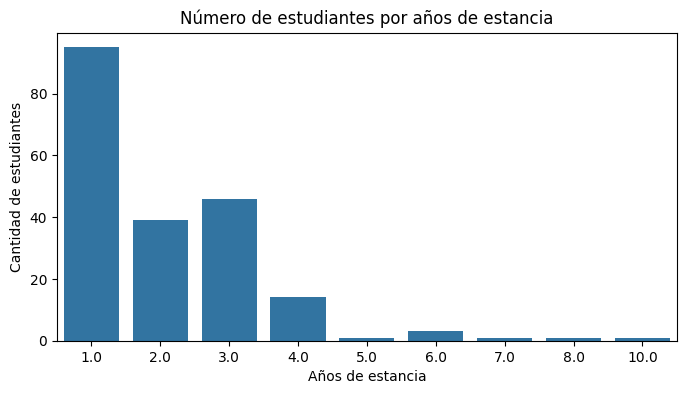

In [6]:
# Antes de analizar los indicadores de salud mental, se examina el tamaño de cada grupo para evaluar la representatividad de los resultados obtenidos.
plt.figure(figsize=(8, 4))

sns.barplot(
    data=resultado,
    x='stay',
    y='count_int'
)

plt.title('Número de estudiantes por años de estancia')
plt.xlabel('Años de estancia')
plt.ylabel('Cantidad de estudiantes')

plt.show()

## Evolución de los indicadores de salud mental

In [7]:
# Se comparan los promedios de depresión (PHQ-9), conexión social (SCS) y estrés de aculturación (ASISS) según los años de estancia en Japón. 
# Para reducir el efecto de muestras muy pequeñas, solo se consideran grupos con al menos 10 estudiantes.
result = resultado[resultado['count_int'] >= 10]

result

,stay,count_int,average_phq,average_scs,average_as
5,4.0,14,8.57,33.93,87.71
6,3.0,46,9.09,37.13,78.00
7,2.0,39,8.28,37.08,77.67
8,1.0,95,7.48,38.11,72.80


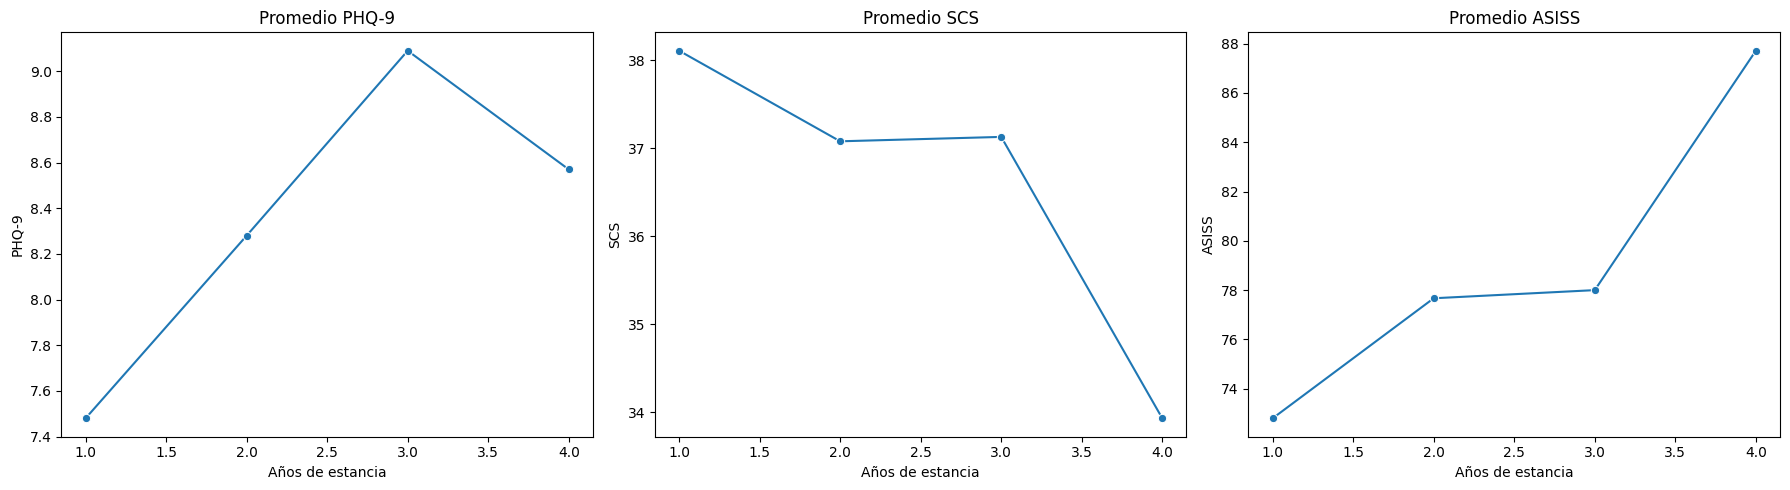

In [8]:
# Visualización de las tendencias de salud mental según los años de estancia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tendencia del promedio de depresión (PHQ-9)
sns.lineplot(
    data=result,
    x='stay',
    y='average_phq',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Promedio PHQ-9')
axes[0].set_xlabel('Años de estancia')
axes[0].set_ylabel('PHQ-9')

# Tendencia del promedio de conexión social (SCS)
sns.lineplot(
    data=result,
    x='stay',
    y='average_scs',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Promedio SCS')
axes[1].set_xlabel('Años de estancia')
axes[1].set_ylabel('SCS')

# Tendencia del promedio de estrés de aculturación (ASISS)
sns.lineplot(
    data=result,
    x='stay',
    y='average_as',
    marker='o',
    ax=axes[2]
)
axes[2].set_title('Promedio ASISS')
axes[2].set_xlabel('Años de estancia')
axes[2].set_ylabel('ASISS')

plt.tight_layout()
plt.show()

## Hallazgos principales

- La mayor parte de los estudiantes internacionales de la muestra tiene entre uno y cuatro años de estancia en Japón.
- Los niveles promedio de depresión (PHQ-9) muestran una tendencia moderadamente ascendente entre el primer y tercer año de estancia, seguida de una ligera disminución en el cuarto año.
- La conexión social (SCS) se mantiene relativamente estable durante los primeros tres años, aunque presenta una disminución en el cuarto año.
- El estrés de aculturación (ASISS) presenta una tendencia ascendente conforme aumenta la duración de la estancia, alcanzando su valor más alto entre los estudiantes con cuatro años de residencia.
- Los grupos con cinco o más años de permanencia presentan muy pocas observaciones, por lo que sus resultados no fueron considerados en el análisis principal.

## Limitaciones

- El análisis es descriptivo y no permite establecer relaciones causales.
- Los grupos con mayor duración de estancia presentan tamaños de muestra reducidos, lo que limita la confiabilidad de las estimaciones para esos casos.
- No se consideraron variables potencialmente relevantes como edad, nivel académico o dominio del idioma.
- Las diferencias observadas entre grupos no fueron evaluadas mediante pruebas estadísticas de significancia.

## Conclusiones

El análisis descriptivo sugiere que la duración de la estancia podría estar asociada con cambios moderados en algunos indicadores de salud mental entre estudiantes internacionales. Mientras que los niveles de depresión y conexión social muestran variaciones relativamente pequeñas durante los primeros años de residencia, el estrés de aculturación presenta una tendencia creciente conforme aumenta el tiempo de estancia.

Dado que el análisis se basa en estadísticas descriptivas y no controla otros factores potencialmente relevantes, los resultados deben interpretarse como evidencia exploratoria y no como una relación causal entre la duración de la estancia y la salud mental.